① グラフ変換の準備

In [2]:
import torch
from torch_geometric.data import Data
from rdkit import Chem

ATOM_LIST = ["H", "C", "N", "O", "F"]
HYBRIDIZATION_LIST = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
]
BOND_TYPE_LIST = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

def one_hot(value, choices):
    return [1.0 if value == c else 0.0 for c in choices]

def atom_features(atom):
    features = []
    features += one_hot(atom.GetSymbol(), ATOM_LIST)
    features += one_hot(atom.GetHybridization(), HYBRIDIZATION_LIST)
    features.append(float(atom.GetDegree()))
    features.append(float(atom.GetFormalCharge()))
    features.append(float(atom.GetTotalNumHs()))
    features.append(1.0 if atom.GetIsAromatic() else 0.0)
    features.append(1.0 if atom.IsInRing() else 0.0)
    return features

def bond_features(bond):
    features = []
    features += one_hot(bond.GetBondType(), BOND_TYPE_LIST)
    features.append(1.0 if bond.GetIsConjugated() else 0.0)
    features.append(1.0 if bond.IsInRing() else 0.0)
    return features

def mol_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    node_feats = [atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(node_feats, dtype=torch.float)

    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feats = bond_features(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [feats, feats]

    if len(edge_indices) == 0:  # 単原子分子（結合なし）の場合
        edge_indices = [[0, 0]]
        edge_attrs = [[0.0] * (len(BOND_TYPE_LIST) + 2)]

    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

② CSV読み込み → グラフ化

In [8]:
import pandas as pd
from torch_geometric.loader import DataLoader

def build_graph_list(df):
    data_list = []
    for smiles, gap in zip(df["smiles"], df["gap_eV"]):
        graph = mol_to_graph(smiles, gap)
        if graph is not None:
            data_list.append(graph)
    return data_list

train_df = pd.read_csv("../train/qm9_smiles_gap_eV.csv")
val_df = pd.read_csv("../val/qm9_smiles_gap_eV.csv")

train_data = build_graph_list(train_df)
val_data = build_graph_list(val_df)

print(f"train: グラフ化できた分子数 {len(train_data)} / 全体 {len(train_df)}")
print(f"val: グラフ化できた分子数 {len(val_data)} / 全体 {len(val_df)}")

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

train: グラフ化できた分子数 107040 / 全体 107040
val: グラフ化できた分子数 13381 / 全体 13381


③ GCNモデル定義

In [6]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GCNRegressor(nn.Module):
    def __init__(self, node_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList([GCNConv(node_dim, hidden_dim)])
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.head(x).squeeze(-1)

④ 学習ループ

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
node_dim = data_list[0].x.shape[1]

model = GCNRegressor(node_dim=node_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.L1Loss()  # MAE

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        if train:
            optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(pred, batch.y)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

N_EPOCHS = 30
for epoch in range(1, N_EPOCHS + 1):
    train_mae = run_epoch(train_loader, train=True)
    val_mae = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch:02d}: train MAE = {train_mae:.4f} / val MAE = {val_mae:.4f}")

Epoch 01: train MAE = 0.8097 / val MAE = 0.4733
Epoch 02: train MAE = 0.4291 / val MAE = 0.4087
Epoch 03: train MAE = 0.3817 / val MAE = 0.3497
Epoch 04: train MAE = 0.3549 / val MAE = 0.3352
Epoch 05: train MAE = 0.3375 / val MAE = 0.3335
Epoch 06: train MAE = 0.3210 / val MAE = 0.3156
Epoch 07: train MAE = 0.3089 / val MAE = 0.3042
Epoch 08: train MAE = 0.3002 / val MAE = 0.2850
Epoch 09: train MAE = 0.2925 / val MAE = 0.2924
Epoch 10: train MAE = 0.2881 / val MAE = 0.2958
Epoch 11: train MAE = 0.2854 / val MAE = 0.2782
Epoch 12: train MAE = 0.2786 / val MAE = 0.2702
Epoch 13: train MAE = 0.2801 / val MAE = 0.2740
Epoch 14: train MAE = 0.2750 / val MAE = 0.2674
Epoch 15: train MAE = 0.2756 / val MAE = 0.2637
Epoch 16: train MAE = 0.2715 / val MAE = 0.2694
Epoch 17: train MAE = 0.2697 / val MAE = 0.2577
Epoch 18: train MAE = 0.2716 / val MAE = 0.2808
Epoch 19: train MAE = 0.2671 / val MAE = 0.2564
Epoch 20: train MAE = 0.2659 / val MAE = 0.2679
Epoch 21: train MAE = 0.2642 / val MAE =

⑤可視化

最終 val MAE: 0.2476 eV


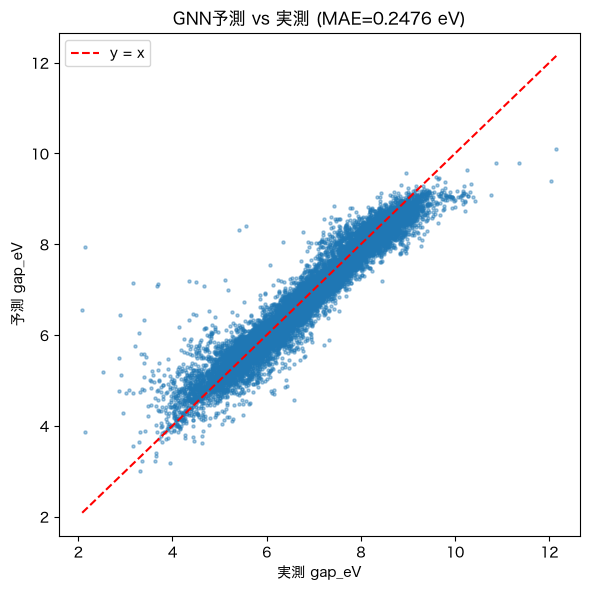

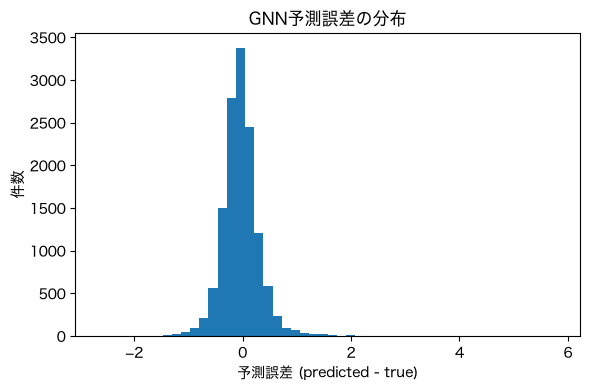

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Hiragino Sans"

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index, batch.batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

final_mae = mean_absolute_error(y_true, y_pred)
print(f"最終 val MAE: {final_mae:.4f} eV")

# 予測値 vs 実測値の散布図
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, s=5, alpha=0.4)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="y = x")
plt.xlabel("実測 gap_eV")
plt.ylabel("予測 gap_eV")
plt.title(f"GNN予測 vs 実測 (MAE={final_mae:.4f} eV)")
plt.legend()
plt.tight_layout()
plt.savefig("results/gnn_pred_vs_true.png", dpi=150)
plt.show()

# 誤差の分布
plt.figure(figsize=(6, 4))
plt.hist(y_pred - y_true, bins=50)
plt.xlabel("予測誤差 (predicted - true)")
plt.ylabel("件数")
plt.title("GNN予測誤差の分布")
plt.tight_layout()
plt.savefig("results/gnn_error_distribution.png", dpi=150)
plt.show()